### 1. Import bibliotek

W tym miejscu importujemy biblioteki, które będą nam potrzebne do analizy danych. Jeżeli w tym miejscu widoczny będzie błąd, to konieczne jest zainstalowanie biblioteki w danym środowisku. W takim wypadku wchodzimy w terminal, aktywujemy środowisko pracy, instalujemy biblioteki (pip install X). Warto też sprawdzić ich zainstalowane wersje (oraz samego Pythona), by szukać właściwej ich dokumentacji.

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import sklearn as sl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [ ]:
print(f'Python: {sys.version.split()[0]}')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Sklearn: {sl.__version__}')
print(f'Matplotlib: {mpl.__version__}')
print(f'Seaborn: {sns.__version__}')

Python: 3.12.12
NumPy: 2.0.2
Pandas: 2.2.2
Sklearn: 1.6.1
Matplotlib: 3.10.0
Seaborn: 0.13.2


### 2. Przygotowanie danych do analizy

Jeżeli dane są na naszym dysku Google, powinniśmy go najpierw zamontować.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Data')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Użyjemy w tym miejscu biblioteki pandas, którą zaimportowaliśmy jako pd. Chcemy ją wykorzystać do wczytania danych, z którymi będziemy w dalszej kolejności pracować. Trzeba uważać w tym miejscu na sposób rozdzielenia danych, z których korzystamy.

In [ ]:
df = pd.read_csv("DSP_4.csv", sep=';')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   objawy   60 non-null     int64  
 1   wiek     55 non-null     float64
 2   choroby  60 non-null     int64  
 3   wzrost   55 non-null     float64
 4   leki     60 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.5 KB


,objawy,wiek,choroby,wzrost,leki
0,1,NaN,0,170.0,2
1,1,65.0,0,NaN,3
2,1,55.0,0,182.0,4
3,1,44.0,0,187.0,3
4,1,77.0,0,165.0,2


Możemy wykorzystać columns do wyświetlenia nazw kolumn, które występują w naszych danych. W przypadku mniejszej ilości danych, to nie ma większego znaczenia, ale przy dużych plikach z danymi, może nam to pomóc w analizie danych.

In [ ]:
df.columns

Index(['objawy', 'wiek', 'choroby', 'wzrost', 'leki'], dtype='object')

Zanim przejdziemy dalej powinniśmy sprawdzić czy w naszym zbiorze występują przypadki braku danych. Jeżeli istnieją, to coś musimy z nimi zrobić. Użycie isnull pozwala na uzyskanie tylko prostej informacji czy występują, czy też nie występują braki w danych.

In [ ]:
df.isnull().any()

,0
objawy,False
wiek,True
choroby,False
wzrost,True
leki,False


Jeżeli ustalimy, że mamy braki danych, to musimy ustalić sposób, w który zamienimy je na inną wartość. Mamy do wyboru kilka możliwości. Możemy wypełnić wszystkie brakujące wartości jakimiś z góry ustalonymi, np. 0. Możemy też użyć średniej wartości z danej zmiennej lub mediany.

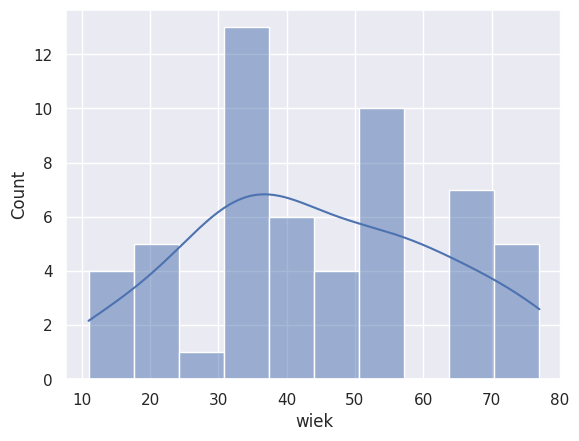

In [ ]:
sns.histplot(df, x='wiek', bins=10, kde=True);

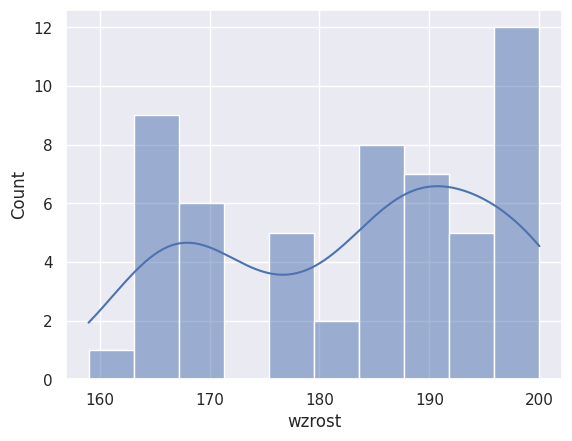

In [ ]:
sns.histplot(df, x='wzrost', bins=10, kde=True);

In [ ]:
df['wiek'].agg(['mean', 'median'])

,wiek
mean,44.163636
median,43.000000


In [ ]:
df['wzrost'].agg(['mean', 'median'])

,wzrost
mean,183.345455
median,187.000000


In [ ]:
df['objawy'].mode()[0]

np.int64(2)

In [ ]:
df_2 = df.fillna(df.median())

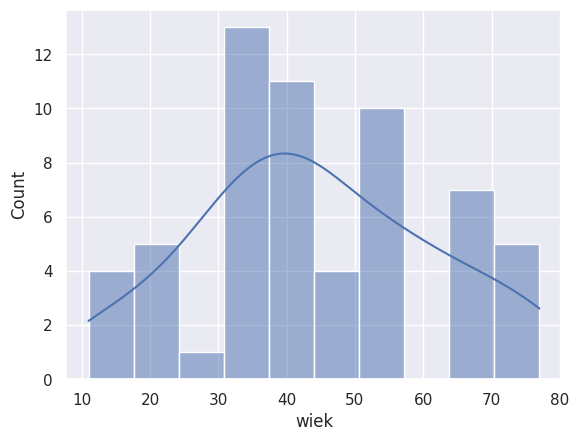

In [ ]:
sns.histplot(df_2, x='wiek', bins=10, kde=True);

Możemy się upewnić, że rozwiązaliśmy problem wszystkich braków danych. Teraz powinno wszędzie wyświetlać się "False"

In [ ]:
df_2.isnull().any()

,0
objawy,False
wiek,False
choroby,False
wzrost,False
leki,False


### 3. Podstawowe statystyki opisowe

In [ ]:
print(df["wiek"].mean())
# średnia dla zmiennej wieku
print(round(df["wiek"].mean(), 2))
# średnia dla zmiennej wieku, ale w zaokrągleniu do drugiego miejsca po przecinku
print(df["wiek"].median())
# mediana dla zmiennej wieku
print(df['wiek'].max())
# maksymalna wartość dla zmiennej wieku
print(df['wiek'].min())
# minimalna wartość dla zmiennej wieku
print(df['wiek'].var())
# wariancja dla zmiennej wieku
print(round(df['wiek'].std(), 2))
# w ten sposób obliczamy odchylenie standardowe
print(df['wiek'].max() - df['wiek'].min())
# możemy odjąć wartość maksymalną od minimalnej - otrzymamy rozstęp danych
print(df['wiek'].quantile([.25, .5, .75]))
# w ten sposób możemy wygenerować kwantyle dla danej zmiennej

44.163636363636364
44.16
43.0
77.0
11.0
341.9171717171717
18.49
66.0
0.25    32.0
0.50    43.0
0.75    55.5
Name: wiek, dtype: float64


In [ ]:
round(df.describe(), 2)
# możemy również przedstawić podstawowe statystyki opisowe dla wszystkich zmiennych równocześnie

,objawy,wiek,choroby,wzrost,leki
count,60.00,55.00,60.00,55.00,60.00
mean,2.53,44.16,1.42,183.35,2.50
std,1.29,18.49,1.62,12.56,1.03
min,1.00,11.00,0.00,159.00,1.00
25%,2.00,32.00,0.00,169.00,2.00
50%,2.00,43.00,1.00,187.00,2.50
75%,4.00,55.50,2.00,194.00,3.00
max,5.00,77.00,5.00,200.00,4.00


In [ ]:
df['wiek'].groupby(df['objawy']).describe()
# w ten sposób możemy sprawdzić w jaki sposób nasilenie objawów różnicuje poszczególne statystyki opisowe

,count,mean,std,min,25%,50%,75%,max
objawy,,,,,,,,
1,12.0,60.916667,10.858246,44.0,54.75,64.0,65.50,77.0
2,20.0,28.200000,9.817278,11.0,21.00,32.0,34.00,42.0
3,7.0,56.571429,11.970201,43.0,49.00,55.0,62.00,76.0
4,10.0,56.000000,13.944334,34.0,46.50,54.5,65.00,76.0
5,6.0,29.666667,10.211105,12.0,26.75,32.5,33.75,42.0


In [ ]:
df.groupby(df['objawy']).describe().T

objawy                  1           2           3           4           5
wiek    count   12.000000   20.000000    7.000000   10.000000    6.000000
        mean    60.916667   28.200000   56.571429   56.000000   29.666667
        std     10.858246    9.817278   11.970201   13.944334   10.211105
        min     44.000000   11.000000   43.000000   34.000000   12.000000
        25%     54.750000   21.000000   49.000000   46.500000   26.750000
        50%     64.000000   32.000000   55.000000   54.500000   32.500000
        75%     65.500000   34.000000   62.000000   65.000000   33.750000
        max     77.000000   42.000000   76.000000   76.000000   42.000000
choroby count   14.000000   22.000000    8.000000   10.000000    6.000000
        mean     2.000000    0.636364    0.625000    3.200000    1.000000
        std      2.183857    0.657952    0.517549    1.549193    0.894427
        min      0.000000    0.000000    0.000000    0.000000    0.000000
        25%      0.000000    0.000000    0.000000    2.250000    0.250000
        50%      1.000000    1.000000    1.000000    3.500000    1.000000
        75%      4.000000    1.000000    1.000000    4.000000    1.750000
        max      5.000000    2.000000    1.000000    5.000000    2.000000
wzrost  count   12.000000   20.000000    8.000000    9.000000    6.000000
        mean   177.333333  186.300000  181.500000  182.555556  189.166667
        std      9.975728   12.823088   13.907860   13.267546   11.788412
        min    164.000000  159.000000  166.000000  166.000000  168.000000
        25%    168.750000  176.000000  167.750000  168.000000  187.000000
        50%    180.000000  190.000000  182.000000  187.000000  190.500000
        75%    187.000000  198.000000  191.250000  190.000000  197.750000
        max    190.000000  200.000000  200.000000  200.000000  200.000000
leki    count   14.000000   22.000000    8.000000   10.000000    6.000000
        mean     2.642857    2.590909    2.000000    2.300000    2.833333
        std      1.008208    1.140555    0.755929    0.948683    1.169045
        min      1.000000    1.000000    1.000000    1.000000    1.000000
        25%      2.000000    2.000000    1.750000    2.000000    2.250000
        50%      3.000000    3.000000    2.000000    2.000000    3.000000
        75%      3.000000    3.750000    2.250000    3.000000    3.750000
        max      4.000000    4.000000    3.000000    4.000000    4.000000

Dużo informacji jesteśmy w stanie uzyskać przy wykorzystaniu analizy korelacji. Możemy dzięki niej uzyskać wgląd w ciekawe zależności międy danymi i odkryć prawidłowości interesujące z naukowego lub biznesowego punktu widzenia.

In [ ]:
df.corr()
# przy użyciu tego prostego kodu uzyskujemy współczynniki korelacji między naszymi zmiennymi

,objawy,wiek,choroby,wzrost,leki
objawy,1.000000,-0.105504,0.110512,0.167664,-0.050666
wiek,-0.105504,1.000000,0.389564,-0.291871,-0.228091
choroby,0.110512,0.389564,1.000000,0.112124,0.045600
wzrost,0.167664,-0.291871,0.112124,1.000000,0.011842
leki,-0.050666,-0.228091,0.045600,0.011842,1.000000


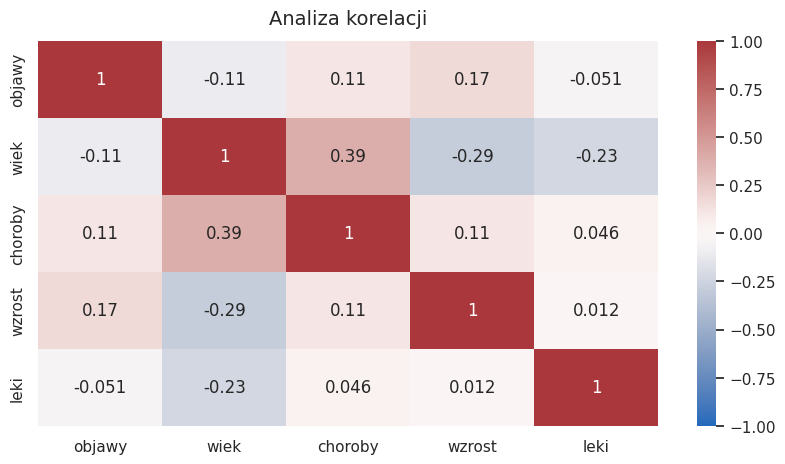

In [ ]:
plt.figure(figsize=(10, 5))
# określamy wielkość tabeli, którą generujemy
heatmap = sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, cmap='vlag')
# odwołujemy się do metody tj. mapy ciepła
heatmap.set_title('Analiza korelacji', fontdict={'fontsize':14}, pad=12);

### 4. Zadanie SUML_1

In [ ]:
from scipy.stats import pearsonr

def calculate_pvalues(df: pd.DataFrame) -> pd.DataFrame:

  """Funkcja wylicza p-wartości i zwraca je w nowej ramce."""

  pvalues = pd.DataFrame(
        columns=df.columns,
        index=df.columns,
        dtype=float
    )

  np.fill_diagonal(pvalues.values, 0.0)

  for i, r in enumerate(df.columns):
      for c in df.columns[i+1:]:
          p_val = pearsonr(df[r], df[c])[1]
          pvalues.loc[r, c] = p_val
          pvalues.loc[c, r] = p_val  # bo jest symetryczna

  return pvalues



In [ ]:
pvalue_df = calculate_pvalues(df_2)
pvalue_df

,objawy,wiek,choroby,wzrost,leki
objawy,0.000000,0.450661,0.400575,0.252693,0.700645
wiek,0.450661,0.000000,0.002434,0.047730,0.100383
choroby,0.400575,0.002434,0.000000,0.421494,0.729371
wzrost,0.252693,0.047730,0.421494,0.000000,0.962984
leki,0.700645,0.100383,0.729371,0.962984,0.000000


Liczba przydzielonych gwiazdek jest wprost proporcionalna do istotności statystycznej.

In [ ]:
def add_stars(p_val: float, corr_val: float) -> str:
  """Zwraca korelację + gwiazdki bazując na p-value"""
  stars = ''.join(['*' for threshold in [0.01, 0.05, 0.10] if p_val < threshold])
  return f"{corr_val:.3f}{stars}"

In [ ]:
vectorized_stars = np.vectorize(add_stars)
stars_array = vectorized_stars(pvalue_df.values, df_2.corr().values)
df_corr_sig = pd.DataFrame(stars_array, index=pvalue_df.index, columns=pvalue_df.columns)
df_corr_sig

,objawy,wiek,choroby,wzrost,leki
objawy,1.000***,-0.099,0.111,0.150,-0.051
wiek,-0.099,1.000***,0.384***,-0.257**,-0.214
choroby,0.111,0.384***,1.000***,0.106,0.046
wzrost,0.150,-0.257**,0.106,1.000***,-0.006
leki,-0.051,-0.214,0.046,-0.006,1.000***


In [ ]:
# wypełninie wartości brakujących medianą
df_median_filled = df.fillna(df.median())
df_zero_filled = df.fillna(0)
print(f"Mediana dla zmiennej 'wiek': {df['wiek'].median()}")
print(f"Mediana dla zmiennej 'wzrost': {df['wzrost'].median()}")

Mediana dla zmiennej 'wiek': 43.0
Mediana dla zmiennej 'wzrost': 187.0


Przełóż zdobytą wiedzę, żeby dokonać podstawowej eksploracji nowego zestawu danych. Wczytaj dane z pliku DSP_5.csv​, pamiętając o właściwym określeniu separatora. Sprawdź czy są brakujące dane - jeżeli są, to wypełnij je średnią. Przedstaw średnią, wariancję i rozstęp dla zmiennej hp​. Przedstaw tabelę korelacji dla zmiennych. Czy są jakieś wartości, które szczególnie zwracają uwagę?

In [ ]:
cars_raw_df = pd.read_csv("DSP_5.csv", sep=';')
cars_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      31 non-null     float64
 5   drat    32 non-null     float64
 6   wt      30 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(6), int64(5), object(1)
memory usage: 3.1+ KB


In [ ]:
missing_data = cars_raw_df.isnull().sum()
missing_data[missing_data > 0].index

Index(['hp', 'wt'], dtype='object')

In [ ]:
# Tworzymy kopię oryginalnej ramki i wypełniamy tylko te kolumny gdzie zidentyfikowano braki
cars_cleaned_df = cars_raw_df.copy()
for col in missing_data[missing_data > 0].index:
  cars_cleaned_df[col] = cars_cleaned_df[col].fillna(cars_cleaned_df[col].median())

In [ ]:
cars_cleaned_df['hp'].describe()

,hp
count,32.000000
mean,142.875000
std,66.273505
min,52.000000
25%,96.500000
50%,123.000000
75%,180.000000
max,335.000000


In [ ]:
hp_mean = cars_cleaned_df['hp'].mean()
hp_variance = cars_cleaned_df['hp'].var()
hp_range = cars_cleaned_df['hp'].max() - cars_cleaned_df['hp'].min()
print(f"{hp_mean=}")
print(f"{hp_variance=}")
print(f"{hp_range=}")

hp_mean=np.float64(142.875)
hp_variance=4392.177419354839
hp_range=283.0


In [ ]:
cars_corr_df = cars_cleaned_df.select_dtypes(include='number').corr()
cars_corr_df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.736074,0.681172,-0.864420,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.800937,-0.699938,0.776758,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.761122,-0.710214,0.885381,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.736074,0.800937,0.761122,1.000000,-0.479081,0.643410,-0.651646,-0.696530,-0.203260,-0.074713,0.732056
drat,0.681172,-0.699938,-0.710214,-0.479081,1.000000,-0.711908,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.864420,0.776758,0.885381,0.643410,-0.711908,1.000000,-0.176005,-0.557853,-0.680961,-0.580343,0.426549
qsec,0.418684,-0.591242,-0.433698,-0.651646,0.091205,-0.176005,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.696530,0.440278,-0.557853,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.203260,0.712711,-0.680961,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.074713,0.699610,-0.580343,-0.212682,0.206023,0.794059,1.000000,0.274073


In [ ]:
# wykorzystanie kodu z poprzedniego zadania
cars_p_values = calculate_pvalues(cars_corr_df)
cars_stars_array = vectorized_stars(cars_p_values.values, cars_corr_df.values)
cars_corr_sig_df = pd.DataFrame(cars_stars_array, index=cars_p_values.index, columns=cars_p_values.columns)
cars_corr_sig_df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000***,-0.852***,-0.848***,-0.736***,0.681***,-0.864***,0.419**,0.664***,0.600***,0.480***,-0.551***
cyl,-0.852***,1.000***,0.902***,0.801***,-0.700***,0.777***,-0.591***,-0.811***,-0.523***,-0.493**,0.527***
disp,-0.848***,0.902***,1.000***,0.761***,-0.710***,0.885***,-0.434**,-0.710***,-0.591***,-0.556***,0.395***
hp,-0.736***,0.801***,0.761***,1.000***,-0.479***,0.643***,-0.652***,-0.697***,-0.203**,-0.075*,0.732***
drat,0.681***,-0.700***,-0.710***,-0.479***,1.000***,-0.712***,0.091,0.440***,0.713***,0.700***,-0.091*
wt,-0.864***,0.777***,0.885***,0.643***,-0.712***,1.000***,-0.176*,-0.558***,-0.681***,-0.580***,0.427**
qsec,0.419**,-0.591***,-0.434**,-0.652***,0.091,-0.176*,1.000***,0.745***,-0.230,-0.213,-0.656***
vs,0.664***,-0.811***,-0.710***,-0.697***,0.440***,-0.558***,0.745***,1.000***,0.168*,0.206*,-0.570***
am,0.600***,-0.523***,-0.591***,-0.203**,0.713***,-0.681***,-0.230,0.168*,1.000***,0.794***,0.058
gear,0.480***,-0.493**,-0.556***,-0.075*,0.700***,-0.580***,-0.213,0.206*,0.794***,1.000***,0.274


W tym zbiorze danych waga (wt) jest najistotniejszym predyktorem ekonomii paliwa (mpg). Samochody ze skrzynią biegów 1 (prawdopodobnie manual) są generalnie lżejsze i bardziej efektywne paliwowo, natomiast moc (hp) jest oczywiście mocno związana z pojemnością silnika i typem napędu.

In [ ]:
# dane z pliku DSP_2.csv
heart_attack_data_df = pd.read_csv("DSP_2.csv", sep = ',')
heart_attack_data_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
# odpowiednie formatowanie liczb jako zmiennoprzecinkowe
numeric_features = heart_attack_data_df.select_dtypes(include=['int64', 'float64']).columns
heart_attack_data_df[numeric_features] = heart_attack_data_df[numeric_features].astype(float)

In [ ]:
# liczba kolumn (wraz z ich nazwami)
print(f"Liczba kolumn: {len(heart_attack_data_df.columns)}")
print(f"\nNazwy kolumn:")
for i, col in enumerate(heart_attack_data_df.columns, 1):
    print(f"{i}. {col}")

Liczba kolumn: 12

Nazwy kolumn:
1. Age
2. Sex
3. ChestPainType
4. RestingBP
5. Cholesterol
6. FastingBS
7. RestingECG
8. MaxHR
9. ExerciseAngina
10. Oldpeak
11. ST_Slope
12. HeartDisease


In [ ]:
#  liczba wierszy (obserwacji), ewentualne braki danych
print(f"Liczba wierszy: {len(heart_attack_data_df)}")
heart_attack_data_df.isnull().any()

Liczba wierszy: 918


,0
Age,False
Sex,False
ChestPainType,False
RestingBP,False
Cholesterol,False
FastingBS,False
RestingECG,False
MaxHR,False
ExerciseAngina,False
Oldpeak,False


In [ ]:
# ściągawka do pisania queries
unique_feature_values_df = pd.DataFrame(
    [{
        "column": col,
        "unique_values": sorted(heart_attack_data_df[col].unique().tolist()),
        "count": len(heart_attack_data_df[col].unique().tolist())}
    for col in heart_attack_data_df.columns
])
unique_feature_values_df

,column,unique_values,count
0,Age,"[28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35....",50
1,Sex,"[F, M]",2
2,ChestPainType,"[ASY, ATA, NAP, TA]",4
3,RestingBP,"[0.0, 80.0, 92.0, 94.0, 95.0, 96.0, 98.0, 100....",67
4,Cholesterol,"[0.0, 85.0, 100.0, 110.0, 113.0, 117.0, 123.0,...",222
5,FastingBS,"[0.0, 1.0]",2
6,RestingECG,"[LVH, Normal, ST]",3
7,MaxHR,"[60.0, 63.0, 67.0, 69.0, 70.0, 71.0, 72.0, 73....",119
8,ExerciseAngina,"[N, Y]",2
9,Oldpeak,"[-2.6, -2.0, -1.5, -1.1, -1.0, -0.9, -0.8, -0....",53


In [ ]:
# średni wiek oraz odchylenie standardowe w grupie kobiet oraz w grupie mężczyzn
age_stats_by_gender_df = heart_attack_data_df.groupby('Sex')['Age'].agg(['mean', 'std'])
age_stats_by_gender_df

,mean,std
Sex,,
F,52.492228,9.517593
M,53.782069,9.397864


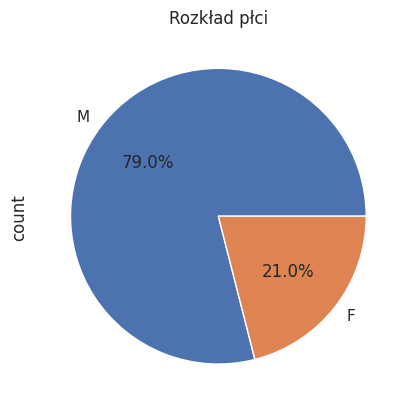

In [ ]:
# odsetek mężczyzn w zbiorze danych
heart_attack_data_df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Rozkład płci')
plt.show()

In [ ]:
# liczby kobiet w wieku od 45 do 50 lat
women_aged_45_to_50_df = heart_attack_data_df[(heart_attack_data_df['Age'] >= 45) & (heart_attack_data_df['Age'] <= 50) & (heart_attack_data_df['Sex'] == 'F')]
women_aged_45_to_50_count = len(women_aged_45_to_50_df)
print(f'{women_aged_45_to_50_count = }')

women_aged_45_to_50_count = 36


In [ ]:
# korelacji pomiędzy zmiennymi, ale wyłącznie dla osób, dla których w zbiorze danych określono, że ich EKG w czasie spoczynku jest w normie (czyli w kolumnie RestingECG występuje obserwacja 'Normal')
normal_ecg_correlation_df = heart_attack_data_df[heart_attack_data_df['RestingECG'] == 'Normal'].select_dtypes(include='number').corr()
normal_ecg_correlation_df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.230469,-0.129005,0.183535,-0.380244,0.246627,0.241428
RestingBP,0.230469,1.000000,0.142830,-0.010983,-0.124514,0.120313,0.051725
Cholesterol,-0.129005,0.142830,1.000000,-0.351044,0.224505,0.028653,-0.276377
FastingBS,0.183535,-0.010983,-0.351044,1.000000,-0.111782,0.078385,0.277575
MaxHR,-0.380244,-0.124514,0.224505,-0.111782,1.000000,-0.195590,-0.427006
Oldpeak,0.246627,0.120313,0.028653,0.078385,-0.195590,1.000000,0.433986
HeartDisease,0.241428,0.051725,-0.276377,0.277575,-0.427006,0.433986,1.000000


In [ ]:
normal_ecg_p_values_df = calculate_pvalues(normal_ecg_correlation_df)
normal_ecg_starred_corr_array = vectorized_stars(normal_ecg_p_values_df.values, normal_ecg_correlation_df.values)
normal_ecg_correlation_with_stars_df = pd.DataFrame(normal_ecg_starred_corr_array, index=normal_ecg_p_values_df.index, columns=normal_ecg_p_values_df.columns)
normal_ecg_correlation_with_stars_df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000***,0.230,-0.129,0.184,-0.380**,0.247,0.241
RestingBP,0.230,1.000***,0.143,-0.011,-0.125,0.120,0.052
Cholesterol,-0.129,0.143,1.000***,-0.351**,0.225,0.029,-0.276*
FastingBS,0.184,-0.011,-0.351**,1.000***,-0.112,0.078,0.278
MaxHR,-0.380**,-0.125,0.225,-0.112,1.000***,-0.196,-0.427**
Oldpeak,0.247,0.120,0.029,0.078,-0.196,1.000***,0.434
HeartDisease,0.241,0.052,-0.276*,0.278,-0.427**,0.434,1.000***
